In [8]:
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm
import nrrd
import SimpleITK as sitk
import plotly.express as px
import plotly.subplots as sp
from diffusers import DDPMScheduler, UNet2DModel
from PIL import Image
import SimpleITK as sitk
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import random
import json
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
from torchmetrics.image.psnr import PeakSignalNoiseRatio


device = torch.device("cuda")

Regular Model

In [9]:
class DiffusionModel(pl.LightningModule):
    def __init__(self, lr=1e-5, num_train_timesteps=1000):
        super().__init__()
        self.save_hyperparameters()
        self.net = UNet2DModel(
            in_channels=1,  # the number of input channels, 3 for RGB images
            out_channels=1,  # the number of output channels
            layers_per_block=2,  # how many ResNet layers to use per UNet block
            block_out_channels=(256, 256, 512, 512, 1024, 1024),  # the number of output channes for each UNet block
            down_block_types=( 
                "DownBlock2D",  # a regular ResNet downsampling block
                "DownBlock2D", 
                "DownBlock2D", 
                "DownBlock2D", 
                "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
                "DownBlock2D",
            ), 
            up_block_types=(
                "UpBlock2D",  # a regular ResNet upsampling block
                "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
                "UpBlock2D", 
                "UpBlock2D", 
                "UpBlock2D", 
                "UpBlock2D"  
            ),
        )
        self.scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps, beta_schedule="linear")
        self.loss_fn = nn.MSELoss()

    def forward(self, x, timesteps):
        return self.net(x, timesteps).sample

    def training_step(self, batch, batch_idx):
        x= batch  # Ignore labels if they exist
        timesteps = torch.randint(0, self.scheduler.config.num_train_timesteps, (x.size(0),), device=self.device).long()
        noise = torch.randn_like(x).to(self.device)
        noisy_images = self.scheduler.add_noise(x, noise, timesteps)

        pred = self(noisy_images, timesteps)  # Model forward pass
        loss = self.loss_fn(pred, noise)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch
        timesteps = torch.randint(0, self.scheduler.config.num_train_timesteps, (x.size(0),), device=self.device)
        outputs = self(x, timesteps)
        loss = self.loss_fn(outputs, x)

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.net.parameters(), lr=self.hparams.lr)
        return optimizer
    

checkpoint_path = "/mnt/raid/home/ajarry/data/outputs_lightning/final53epoch/model.pth"
model = DiffusionModel()
state_dict = torch.load(checkpoint_path)
model.load_state_dict(state_dict, strict=False)
model = model.to(device)

# Define the scheduler (make sure it matches the one used in training)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")

# Set up sampling parameters
image_size = (1, 1, 256, 256)  # Adjust shape (batch, channels, height, width)
num_inference_steps =50  # Can be reduced for faster generation
scheduler.set_timesteps(num_inference_steps)
# Start with pure noise
noisy_image = torch.randn(image_size).to(device)

# Sample timesteps
timesteps = scheduler.timesteps.to(device)



B-Maps Model

In [10]:
def generate_bmap(H, W, t, T, epsilon=0.03):
    gamma = 1.0 - (t / T) * epsilon
    gradient = np.linspace(1.0, gamma, H).reshape(H, 1)
    B_t = np.repeat(gradient, W, axis=1)
    return torch.tensor(B_t, dtype=torch.float32)

class BDiffusionModel(pl.LightningModule):
    def __init__(self, lr=1e-5, num_train_timesteps=1000):
        super().__init__()
        self.save_hyperparameters()
        self.net = UNet2DModel(
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(256, 256, 512, 512, 1024, 1024),
            down_block_types=(
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",
                "DownBlock2D",
            ),
            up_block_types=(
                "UpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D"
            ),
        )
        self.scheduler = DDPMScheduler(num_train_timesteps=num_train_timesteps, beta_schedule="linear")
        self.loss_fn = nn.MSELoss()

    def forward(self, x, timesteps):
        return self.net(x, timesteps).sample

    def training_step(self, batch, batch_idx):
        x = batch
        B, C, H, W = x.shape
        T = self.scheduler.config.num_train_timesteps
        timesteps = torch.randint(0, T, (B,), device=self.device).long()

        noise = torch.randn_like(x).to(self.device)
        noisy_images = torch.empty_like(x)

        for i in range(B):
            bmap = generate_bmap(H, W, timesteps[i].item(), T).to(x.device)
            bmap = bmap.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W)
            alpha_t = self.scheduler.alphas_cumprod[timesteps[i]].to(x.device)

            sqrt_alpha_B = torch.sqrt(alpha_t * bmap)
            sqrt_one_minus_alpha_B = torch.sqrt(1.0 - alpha_t * bmap)
            noisy_images[i] = sqrt_alpha_B * x[i] + sqrt_one_minus_alpha_B * noise[i]

        pred = self(noisy_images, timesteps)
        loss = self.loss_fn(pred, noise)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch
        B, C, H, W = x.shape
        T = self.scheduler.config.num_train_timesteps
        timesteps = torch.randint(0, T, (B,), device=self.device).long()

        noise = torch.randn_like(x).to(self.device)
        noisy_images = torch.empty_like(x)

        for i in range(B):
            bmap = generate_bmap(H, W, timesteps[i].item(), T).to(x.device)
            bmap = bmap.unsqueeze(0).unsqueeze(0)
            alpha_t = self.scheduler.alphas_cumprod[timesteps[i]].to(x.device)

            sqrt_alpha_B = torch.sqrt(alpha_t * bmap)
            sqrt_one_minus_alpha_B = torch.sqrt(1.0 - alpha_t * bmap)
            noisy_images[i] = sqrt_alpha_B * x[i] + sqrt_one_minus_alpha_B * noise[i]

        pred = self(noisy_images, timesteps)
        loss = self.loss_fn(pred, noise)

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.net.parameters(), lr=self.hparams.lr)

checkpoint_path = "/mnt/raid/home/ajarry/data/outputs_bmap/output_20250429_100112/model.pth"
model = BDiffusionModel()
state_dict = torch.load(checkpoint_path)
model.load_state_dict(state_dict, strict=False)
model = model.to(device)


Variables

In [11]:
def guidance_loss(image, target):
    return torch.abs(image - target).mean()

scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")


num_inference_steps = 50
guidance_loss_scale = 200
frame = 90


scheduler.set_timesteps(num_inference_steps)
timesteps = scheduler.timesteps.to(device)

data = sitk.GetArrayFromImage(sitk.ReadImage('/mnt/raid/C1_ML_Analysis/simulated_data_export/placenta_simu/FAM-025-0795-1_label11/C4_cut.nrrd'))
totensor = transforms.ToTensor()
target_image = totensor(data[frame]).to(device)


Regular Sampling

In [12]:

x = torch.randn(1, 1, 256, 256).to(device)

for i, t in tqdm(enumerate(scheduler.timesteps)):

    with torch.no_grad():
        noise_pred = model(x, t)

    x = x.detach().requires_grad_()
    x0 = scheduler.step(noise_pred, t, x).pred_original_sample

    loss = guidance_loss(x0, target_image) * guidance_loss_scale
    if i % 10 == 0:
        print(i, "loss:", loss.item())

    cond_grad = -torch.autograd.grad(loss, x)[0]
    x = x.detach() + cond_grad
    x = scheduler.step(noise_pred, t, x).prev_sample

0it [00:00, ?it/s]

0 loss: 96.35452270507812
10 loss: 79.30967712402344
20 loss: 13.593766212463379
30 loss: 12.937675476074219
40 loss: 13.620988845825195


B-Maps Sampling

In [13]:
xb = torch.randn(1, 1, 256, 256).to(device)
def generate_bmap(shape, device="cpu"):
    b, c, h, w = shape
    linear_map = torch.linspace(1.0, 0.0, steps=h, device=device).view(1, 1, h, 1)
    bmap = linear_map.expand(b, c, h, w)
    return bmap

for i, t in tqdm(enumerate(scheduler.timesteps)):

    with torch.no_grad():
        noise_pred = model(xb, t)

    xb = xb.detach().requires_grad_()
    xb0 = scheduler.step(noise_pred, t, xb).pred_original_sample
    bmap = generate_bmap(xb.shape, device)
    xb0 = bmap * xb0 + (1.0 - bmap) * xb0

    loss = guidance_loss(xb0, target_image) * guidance_loss_scale
    if i % 10 == 0:
        print(i, "loss:", loss.item())

    cond_grad = -torch.autograd.grad(loss, xb)[0]
    xb = xb.detach() + cond_grad
    xb = scheduler.step(noise_pred, t, xb).prev_sample

0it [00:00, ?it/s]

0 loss: 86.01513671875
10 loss: 37.96730041503906
20 loss: 13.12391185760498
30 loss: 13.044032096862793
40 loss: 12.504100799560547


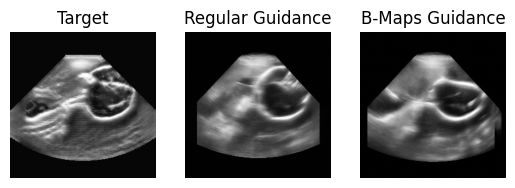

In [14]:
img = x.detach().squeeze(0).cpu().permute(1,2,0)
b_img = xb.detach().squeeze(0).cpu().permute(1,2,0)

fig, ax = plt.subplots(1, 3)
ax[0].imshow(data[frame], cmap="gray")
ax[0].set_title("Target")
ax[0].axis("off")
ax[1].imshow(img, cmap="gray")
ax[1].set_title("Regular Guidance")
ax[1].axis("off")
ax[2].imshow(b_img, cmap="gray")
ax[2].set_title("B-Maps Guidance")
ax[2].axis("off")
plt.show()

In [9]:
parquet = "/mnt/raid/C1_ML_Analysis/CSV_files/extract_frames_Dataset_C_masked_resampled_256_spc075_wscores_meta_noflyto_1e-4.parquet"
root = '/mnt/raid/C1_ML_Analysis'
df = pd.read_parquet(parquet, engine="pyarrow")
num_samples = 5000
df_sampled = df.sample(n=num_samples, random_state=1).reset_index(drop=True)
test_sample = df.sample(n=num_samples, random_state=2).reset_index(drop=True)
class DatasetFromDataFrame(Dataset):
    def __init__(self, root_dir, dataframe, transform=None):
        self.root_dir = root_dir
        self.df = dataframe
        self.transform = transform
        self.image_paths = []


        for i in range(self.df.shape[0]):
            img_name = self.df.iloc[i,0]
            self.image_paths.append(os.path.join(self.root_dir,img_name))
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    
        if self.transform:
            image = self.transform(image)

        return image

##################################################################################################################################################################################################################################################

class CustomDataset(Dataset):
    def __init__(self, g_dict, transform=None):
        self.transform = transform
        self.g_images = []
        self.g_dict = g_dict


        for g_path in self.g_dict:
            for i in self.g_dict[g_path]:
                g_file_path = os.path.join(g_path, os.listdir(g_path)[i])
                g_data = sitk.GetArrayFromImage(sitk.ReadImage(g_file_path))
                self.g_images.append(g_data)

    def __len__(self):
        return len(self.g_images)
    
    def __getitem__(self, idx):
        g_image = self.g_images[idx]*255
        if self.transform:
            g_image = self.transform(g_image)

        return g_image



In [10]:
gpreprocess = transforms.Compose([                        
    transforms.Lambda(lambda x: x.astype(np.uint8)), 
    transforms.ToPILImage(),  
    transforms.Resize((299, 299)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),                       
])
print("Loading real data")
real_dataset = DatasetFromDataFrame(root_dir=root, dataframe=df_sampled, transform=gpreprocess)
real_loader = DataLoader(real_dataset, batch_size=32, shuffle=False)
print("Real data loaded")
test_dataset = DatasetFromDataFrame(root_dir=root, dataframe=test_sample, transform=gpreprocess)
test_loader = DataLoader(real_dataset, batch_size=32, shuffle=False)

print("Loading generated data")
with open("dictionary_guided.json","r") as f:
    dictionary_guided = json.load(f)  
     
with open("dictionary_bmap.json","r") as f:
    dictionary_bmap = json.load(f)  

g_full_dataset = CustomDataset(g_dict=dictionary_guided,transform=gpreprocess)
b_full_dataset = CustomDataset(g_dict=dictionary_bmap,transform=gpreprocess)

num_samples = 5000
indices = random.sample(range(len(g_full_dataset)), num_samples)

subset = Subset(g_full_dataset, indices)
guided_loader = DataLoader(subset, batch_size=32, shuffle = False)

subset = Subset(b_full_dataset, indices)
bmap_loader = DataLoader(subset, batch_size=32, shuffle = False)
print("Generated data loaded")

fid = FrechetInceptionDistance(feature=2048).cuda()  # Move to GPU if available

# Update FID with real and generated images
with torch.no_grad():
    for batch in tqdm(real_loader, desc="Real"):
        batch = (batch.clamp(0, 1) * 255).to(torch.uint8)
        fid.update(batch.cuda(), real=True)

    for batch in tqdm(guided_loader, desc="Generated"):
        batch = (batch.clamp(0, 1) * 255).to(torch.uint8)
        fid.update(batch.cuda(), real=False)

# Compute final FID score
fid_score = fid.compute()
print(f"FID Score: {fid_score.item():.2f}")

Loading real data
Real data loaded
Loading generated data
Generated data loaded


Real:   0%|          | 0/157 [00:00<?, ?it/s]

Generated:   0%|          | 0/157 [00:00<?, ?it/s]

FID Score: 54.07


In [11]:

# Initialize LPIPS (e.g., using AlexNet)
lpips = LearnedPerceptualImagePatchSimilarity(net_type='alex').cuda()

lpips_scores = []

# Make sure both loaders return images normalized to [-1, 1] and shaped [B, 3, H, W]
for real_batch, gen_batch in tqdm(zip(guided_loader, bmap_loader), total=min(len(guided_loader), len(bmap_loader))):
    real_batch = real_batch.cuda()
    gen_batch = gen_batch.cuda()

    # If needed, convert from [0, 1] to [-1, 1]
    real_batch = real_batch * 2 - 1
    gen_batch = gen_batch * 2 - 1

    # Compute LPIPS for batch
    score = lpips(gen_batch, real_batch)
    lpips_scores.append(score.item())

# Average LPIPS score across all batches
average_lpips = sum(lpips_scores) / len(lpips_scores)
print("Average LPIPS:", average_lpips)



  0%|          | 0/157 [00:00<?, ?it/s]

Average LPIPS: 0.2790325202380016


In [13]:


# Initialize SSIM metric
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).cuda()

ssim_scores = []

for real_batch, gen_batch in tqdm(zip(guided_loader, bmap_loader), total=min(len(guided_loader), len(bmap_loader))):
    real_batch = real_batch.cuda()
    gen_batch = gen_batch.cuda()

    # Ensure both are normalized to [0, 1]
    real_batch = real_batch.clamp(0, 1)
    gen_batch = gen_batch.clamp(0, 1)

    # Convert to 3 channels if needed
    if real_batch.shape[1] == 1:
        real_batch = real_batch.repeat(1, 3, 1, 1)
        gen_batch = gen_batch.repeat(1, 3, 1, 1)

    # Compute SSIM for batch
    score = ssim(gen_batch, real_batch)
    ssim_scores.append(score.item())

# Average SSIM
avg_ssim = sum(ssim_scores) / len(ssim_scores)
print("Average SSIM:", avg_ssim)


  0%|          | 0/157 [00:00<?, ?it/s]

Average SSIM: 0.669116159153592


In [14]:
# Initialize PSNR metric
psnr = PeakSignalNoiseRatio(data_range=1.0).cuda()

psnr_scores = []

# Assume real_loader and guided_loader are matched (same order & size)
for real_batch, gen_batch in tqdm(zip(bmap_loader, guided_loader), total=min(len(bmap_loader), len(guided_loader))):
    real_batch = real_batch.cuda()
    gen_batch = gen_batch.cuda()

    # Ensure values are in [0, 1]
    real_batch = real_batch.clamp(0, 1)
    gen_batch = gen_batch.clamp(0, 1)

    # Convert grayscale to 3 channels if needed
    if real_batch.shape[1] == 1:
        real_batch = real_batch.repeat(1, 3, 1, 1)
        gen_batch = gen_batch.repeat(1, 3, 1, 1)

    # Compute PSNR for batch
    score = psnr(gen_batch, real_batch)
    psnr_scores.append(score.item())

# Average PSNR over all batches
avg_psnr = sum(psnr_scores) / len(psnr_scores)
print("Average PSNR:", avg_psnr)


  0%|          | 0/157 [00:00<?, ?it/s]

Average PSNR: 15.007238424507676
